In [94]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, linregress
import pandas as pd
from matplotlib.ticker import MultipleLocator

1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


In [2]:
N = 200
x = np.random.normal(0, 1, N)

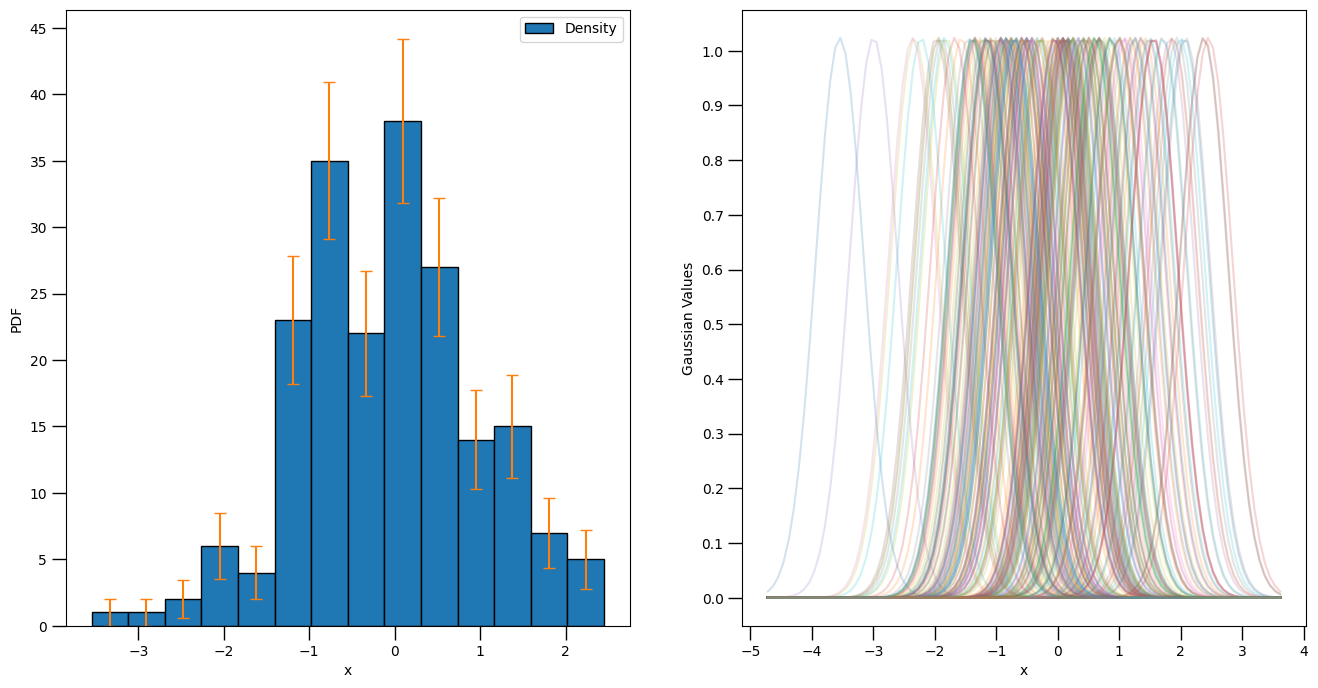

In [3]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(16, 8), )
nbin = int(np.sqrt(N))
n, bins, _ = ax1.hist(x, bins = nbin, label = 'Density', edgecolor='black') 

ax1.set_ylabel("PDF")
ax1.set_xlabel("x")
ax1.xaxis.set_major_locator(MultipleLocator(1)) #step of ticks
ax1.yaxis.set_major_locator(MultipleLocator(5))
ax1.tick_params(which='major', width=1.0)
ax1.tick_params(which='major', length=10)
ax1.legend()

err = np.sqrt(n) # Poisson errors
centers = np.array([(bins[i] + bins[i+1]) / 2 for i in range(0, nbin)])
ax1.errorbar(centers, n, yerr=err, linestyle='none', capsize=4)

std = 1.06 * np.std(x) * (np.pow(np.size(x), -0.2))
x_vals = np.linspace(min(x) - 3*std, max(x) + 3*std, 100) #-> evaluated in the same points
gauss = []
for i in range(N):
    y_vals = norm.pdf(x_vals, loc=x[i], scale=std)
    ax2.plot(x_vals, y_vals, alpha=0.2)
    gauss.append(y_vals)

ax2.set_xlabel("x")
ax2.set_ylabel("Gaussian Values")
ax2.xaxis.set_major_locator(MultipleLocator(1)) #step of ticks
ax2.yaxis.set_major_locator(MultipleLocator(0.1))
ax2.tick_params(which='major', width=1)
ax2.tick_params(which='major', length=10)

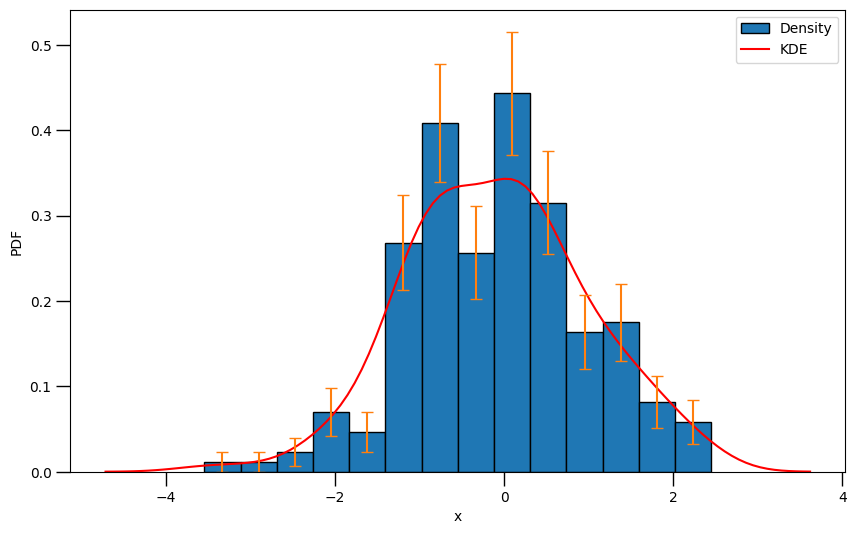

In [4]:
gauss = np.array(gauss)
gauss_sum = np.sum(gauss, axis = 0) # gaussian summed element by element of the same x_vals (not x random)
integral = np.trapezoid(gauss_sum, x_vals)
gauss_sum = gauss_sum / integral

plt.figure(figsize=(10, 6))
n, bins, _ = plt.hist(x, bins = nbin, label = 'Density', density=True, edgecolor='black')  # normalized
plt.plot(x_vals, gauss_sum, color = 'r', label = 'KDE')

centers = np.array([(bins[i] + bins[i+1]) / 2 for i in range(0, nbin)])
bin_width = np.abs(bins[0] - bins[1])
err = np.sqrt(n / (N * bin_width)) # Poisson errors: sigma = sqrt(counts) / (N_tot * deltax) (discrete integral) where n = counts / Ntot*width
plt.errorbar(centers, n, yerr=err, linestyle='none', capsize=4) # capsize ticked limits

plt.ylabel("PDF")
plt.xlabel("x")
plt.tick_params(which='major', width=1.0)
plt.tick_params(which='major', length=10)
plt.legend()
plt.show()

In [5]:
print(f"Integral from KDE:= {integral*bin_width:.6f}") #to compare with the hist we have to dot the bin_width
print(f"Integral from Normalized Histogram:= {N*bin_width:.6f}")
print(f"Difference:={np.abs((integral - N)*bin_width):.6f}")

Integral from KDE:= 85.657756
Integral from Normalized Histogram:= 85.659637
Difference:=0.001881


2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

In [6]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png

Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/mnt/c/Users/kevin/.wget-hsts'. HSTS will be disabled.
--2025-12-04 11:43:10--  https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35 [following]
--2025-12-04 11:43:11--  https://www.dropbox.com/scl/fi/70o67xqfkicx6o3pofl37/two_categories_scatter_plot.png?rlkey=b1wnq5kkwhthz0cevmq0mxf35
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucd1610719f12cb072188b8c22e1.dl.dropboxusercontent.com/cd/0/inline/C2amD5Nh-XuhUdz_DkKss0s2Z0yFoaFDVV

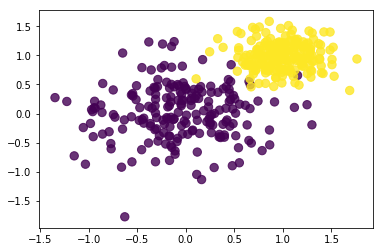

In [7]:
from IPython.display import Image
Image('two_categories_scatter_plot.png')

In [69]:
N = 1000
data1, data2 = np.random.normal(2.3, 3, size=N), np.random.normal(3.5, 2, size=N)
df = pd.DataFrame({"X":data1, "Y":data2})
df['Feature'] = np.where(df['X'] * df['Y'] < 2, 1, 0)

In [70]:
df

,X,Y,Feature
0,0.628426,2.459933,1
1,-3.374595,4.983588,1
2,1.577286,3.225781,0
3,6.014411,0.953469,0
4,4.046657,6.194016,0
...,...,...,...
995,0.532744,2.709135,1
996,3.351372,3.842019,0
997,-0.209638,5.612642,1
998,3.685596,3.552403,0


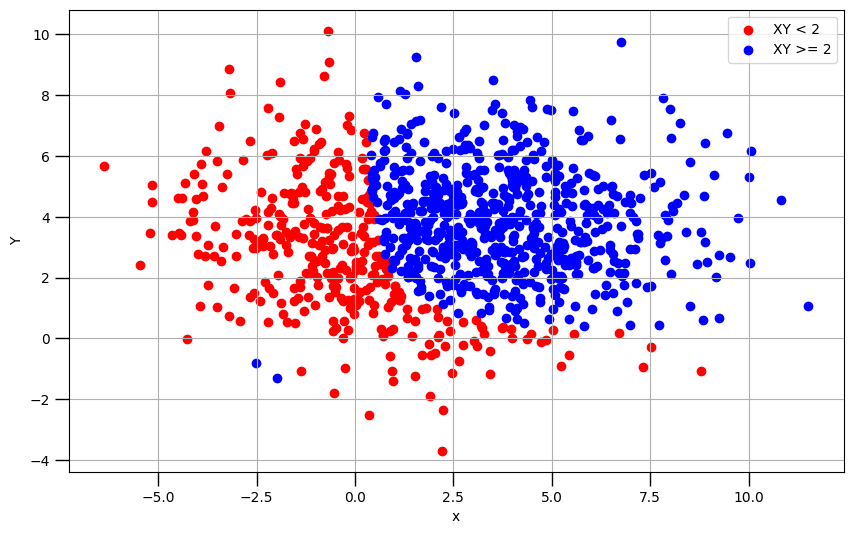

In [72]:
f1 = df[df['Feature'] == 1]
f0 = df[df['Feature'] == 0]

plt.figure(figsize=(10,6))
plt.scatter(f1['X'], f1['Y'], c='Red', marker = 'o', label = 'XY < 2')
plt.scatter(f0['X'], f0['Y'], c='Blue', marker = 'o', label = 'XY >= 2')

plt.ylabel("Y")
plt.xlabel("x")
plt.tick_params(which='major', width=1.0)
plt.tick_params(which='major', length=10)
plt.legend()
plt.grid(True)
plt.show()

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot

In [100]:
import seaborn as sns
data = np.load("residuals_261.npy", allow_pickle=True).item()
df = pd.DataFrame(data)
df

,residuals,distances
0,1.100000,16.0
1,-1.950000,6.3
2,-7.200000,3.4
3,-4.150000,8.4
4,-6.590000,1.7
...,...,...
11126,-0.760000,14.4
11127,0.380000,7.5
11128,0.083333,1.7
11129,0.166667,19.1


In [93]:
df_clean = df[np.abs(df['residuals']) < 2]
df_clean

,residuals,distances
0,1.100000,16.0
1,-1.950000,6.3
8,-0.042857,3.3
9,0.128571,5.3
10,0.085714,15.0
...,...,...
11126,-0.760000,14.4
11127,0.380000,7.5
11128,0.083333,1.7
11129,0.166667,19.1


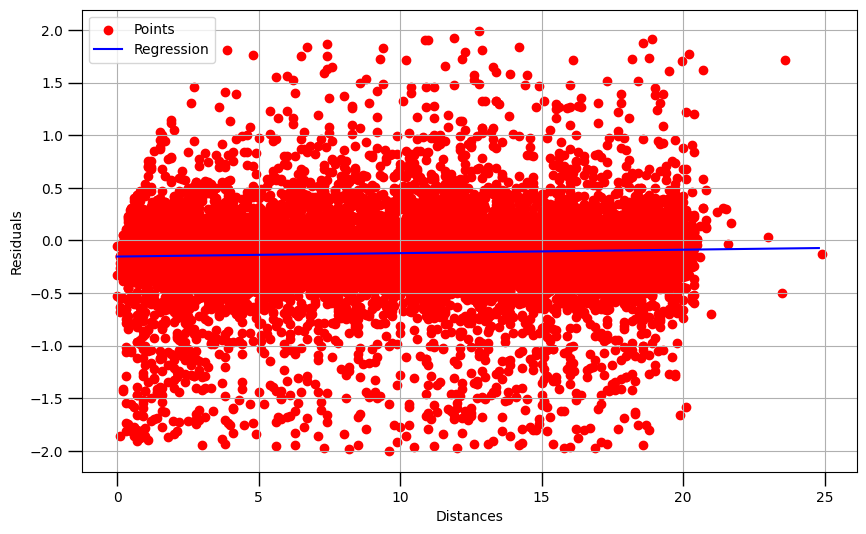

In [114]:
m, q, *_ = linregress(df_clean['distances'], df_clean['residuals'])
x_vals = np.arange(df_clean['distances'].min(), df_clean['distances'].max(), 0.1)

plt.figure(figsize=(10,6))
plt.scatter(df_clean['distances'], df_clean['residuals'], c='Red', marker = 'o', label = 'Points')
plt.plot(x_vals, m*x_vals + q, c='Blue', label = 'Regression')

plt.xlabel("Distances")
plt.ylabel("Residuals")
plt.tick_params(which='major', width=1.0)
plt.tick_params(which='major', length=10)
plt.legend()
plt.grid(True)
plt.show()

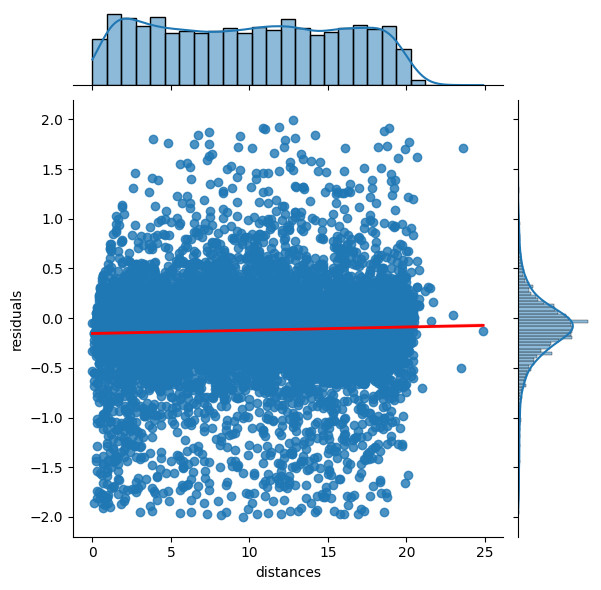

In [117]:
g = sns.jointplot(data=df_clean, x="distances", y="residuals", kind="reg",line_kws={'color':'red', 'linewidth':2})
plt.show()

* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

In [132]:
nbin = 10
x = np.linspace(0, 20, nbin + 1)
residuals = np.array(df_clean['residuals'].values)
indx = np.digitize(df_clean['distances'], x)

y, erry = np.zeros(nbin), np.zeros(nbin)
for i in range(nbin):
    if(len(residuals[indx == i]) == 0):#empty slices
        y[i] = 0
        erry[i] = 0
    else:
        y[i] = residuals[indx == i].mean() #mean on the element masked as digitize
        erry[i] = residuals[indx == i].std()

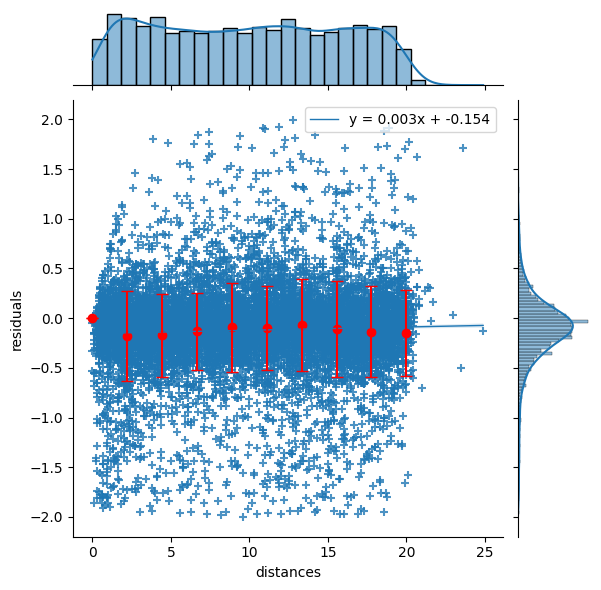

In [164]:
sns.jointplot(data=df_clean, x="distances", y="residuals", kind="reg", marker='+',
              line_kws={'linewidth':1, 'label':f'y = {m:.3f}x + {q:.3f}'})
plt.scatter(np.linspace(0, 20, nbin), y, marker = 'o', color = 'Red')
plt.errorbar(np.linspace(0, 20, nbin), y, yerr=erry, linestyle='none', capsize=4, color='Red')
plt.legend()
plt.show()